In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from google.cloud import bigquery
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.svm import LinearSVC
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer

/Users/sawyermckenney/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/sawyermckenney/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
key_path = "../../../fraud-detection-key.json"

if os.path.exists(key_path):
    client = bigquery.Client.from_service_account_json(key_path)

    query = """
        SELECT * FROM `csci-4022.CSCI.fraud_data`
    """
    print("Fetching the FULL dataset...")
    df = client.query(query).to_dataframe()

    print(f"Success! Loaded {len(df):,} rows.")
    print(df.info())
else:
    print("Key file not found.")

Fetching the FULL dataset...


/Users/sawyermckenney/.local/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Success! Loaded 999,999 rows.
<class 'pandas.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   fraud_bool                        999999 non-null  Int64  
 1   income                            999999 non-null  float64
 2   name_email_similarity             999999 non-null  float64
 3   prev_address_months_count         999999 non-null  Int64  
 4   current_address_months_count      999999 non-null  Int64  
 5   customer_age                      999999 non-null  Int64  
 6   days_since_request                999999 non-null  float64
 7   intended_balcon_amount            999999 non-null  float64
 8   payment_type                      999999 non-null  str    
 9   zip_count_4w                      999999 non-null  Int64  
 10  velocity_6h                       999999 non-null  float64
 11  velocity_24h                     

In [3]:
sentinel_cols = [
    'prev_address_months_count',
    'intended_balcon_amount',
    'bank_months_count',
    'device_distinct_emails_8w'
] # Columns where -1 is missing data instead of NaN

df[sentinel_cols] = df[sentinel_cols].replace(-1, np.nan)

#Categorizing column types
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

#Eliminating fraud target from numeric list
if "fraud_bool" in numeric_cols:
    numeric_cols.remove("fraud_bool")

In [4]:
# Split data into features and target, then into training and test sets
X = df.drop(columns=["fraud_bool"])
y = df["fraud_bool"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
print(df.shape)

(999999, 32)


In [6]:
# Repeat column type categorization for train/test splits
import time
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), #Fills missing values with median for numeric columns
    ("scaler", StandardScaler()) #Normalizes numeric features to have mean=0 and std=1
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), #Fills missing values with the most frequent category for categorical columns
    ("encoder", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01, sparse_output=True)) #One hot encodes categorical features 
])

# Combine pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols), #Applies numeric pipeline to numeric columns
        ("cat", categorical_transformer, categorical_cols) #Applies categorical pipeline to categorical columns
    ]
)
fit_start = time.time()
X_train_processed = preprocessor.fit_transform(X_train) 
X_test_processed = preprocessor.transform(X_test)
fit_end = time.time()
print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print(f"Preprocessing time: {fit_end - fit_start:.2f} seconds")


Processed train shape: (799999, 51)
Processed test shape: (200000, 51)
Preprocessing time: 3.69 seconds


In [7]:
np.random.seed(42)

sample_size = int(0.2 * X_train_processed.shape[0]) # takes arandom 20% of training data
sample_idx = np.random.choice(X_train_processed.shape[0], size=sample_size, replace=False) # Randomly chooses indicies for the sample without replacment 

X_train_sample = X_train_processed[sample_idx] # Grabs the rwos from the features 
y_train_sample = y_train.iloc[sample_idx] # Grabs teh matching labels for the sample

print(f"Training on {X_train_sample.shape[0]} samples")

# Fast linear SVM for large sparse data
# Uses a diffrent optimizer that sacales better with this large amount of data
svm = LinearSVC(C=1.0, class_weight="balanced", random_state=42,max_iter=5000)
fit_start = time.time()
svm.fit(X_train_processed, y_train) # Fits the linear SVM model to the sampled training data
fit_end = time.time()
print(f"Training time: {fit_end - fit_start:.2f} seconds")


# Evaluate on sparse test matrix

threshold = 0.2 # Chose this threshold based on the training set performance to balance recall and precision
pred_start_time = time.time()
svm_pred = svm.predict(X_test_processed)
pred_end_time = time.time()
print(f"Prediction time: {pred_end_time - pred_start_time:.2f} seconds")


print("LINEAR SVM EVALUATION")
print(f"Recall   : {recall_score(y_test, svm_pred):.4f}")
print(f"Precision: {precision_score(y_test, svm_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, svm_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

Training on 159999 samples
Training time: 3.87 seconds
Prediction time: 0.02 seconds
LINEAR SVM EVALUATION
Recall   : 0.7774
Precision: 0.0427
F1-Score : 0.0810

Confusion Matrix:
[[159385  38409]
 [   491   1715]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.81      0.89    197794
         1.0       0.04      0.78      0.08      2206

    accuracy                           0.81    200000
   macro avg       0.52      0.79      0.49    200000
weighted avg       0.99      0.81      0.88    200000



In [8]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1) #Builds a simple KNN classifier
fit_time_start = time.time()
knn.fit(X_train_sample, y_train_sample)
fit_time_end = time.time()
print(f"KNN training time: {fit_time_end - fit_time_start:.2f} seconds")

KNN training time: 0.02 seconds


In [9]:
pred_start_time = time.time()
knn_pred = knn.predict(X_test_processed)
pred_end_time = time.time()
print(f"KNN prediction time: {pred_end_time - pred_start_time:.2f} seconds")

print("KNN EVALUATION")
print(f"Recall   : {recall_score(y_test, knn_pred):.4f}")
print(f"Precision: {precision_score(y_test, knn_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, knn_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, knn_pred))
print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

KNN prediction time: 7.41 seconds
KNN EVALUATION
Recall   : 0.0068
Precision: 0.1744
F1-Score : 0.0131

Confusion Matrix:
[[197723     71]
 [  2191     15]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99    197794
         1.0       0.17      0.01      0.01      2206

    accuracy                           0.99    200000
   macro avg       0.58      0.50      0.50    200000
weighted avg       0.98      0.99      0.98    200000



In [10]:

calibrated_svc = CalibratedClassifierCV(LinearSVC(C=1.0, class_weight="balanced", random_state=42, max_iter=5000), cv=3) # Logistic regression as meta-learner
stacking_clf = StackingClassifier(estimators=[('svc', calibrated_svc), ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))], final_estimator=LogisticRegression(class_weight="balanced"), cv=5, passthrough=False) # Stacking applied to SVM and KNN
fit_start = time.time()
stacking_clf.fit(X_train_sample, y_train_sample) # Fits the stacking method 
fit_end = time.time()
print(f"Stacking training time: {fit_end - fit_start:.2f} seconds")
pred_start_time = time.time()
stacking_pred = stacking_clf.predict(X_test_processed) #Evaluates the stacking method on the test set
pred_end_time = time.time()
print(f"Stacking prediction time: {pred_end_time - pred_start_time:.2f} seconds")

Stacking training time: 18.38 seconds
Stacking prediction time: 7.32 seconds


In [11]:
print("STACKING ENSEMBLE EVALUATION")                                                                                                                                                                                                                                                                                                                                                                   
print(f"Recall   : {recall_score(y_test, stacking_pred):.4f}")                                                                                                                                                 
print(f"Precision: {precision_score(y_test, stacking_pred):.4f}")                                                                                                                                              
print(f"F1-Score : {f1_score(y_test, stacking_pred):.4f}")                                                                                                                                                     
print("\nConfusion Matrix:")                                                                                                                                                                                   
print(confusion_matrix(y_test, stacking_pred))                                                                                                                                                                 
print("\nClassification Report:")                                                                                                                                                                              
print(classification_report(y_test, stacking_pred))

STACKING ENSEMBLE EVALUATION
Recall   : 0.6052
Precision: 0.0703
F1-Score : 0.1259

Confusion Matrix:
[[180135  17659]
 [   871   1335]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.91      0.95    197794
         1.0       0.07      0.61      0.13      2206

    accuracy                           0.91    200000
   macro avg       0.53      0.76      0.54    200000
weighted avg       0.98      0.91      0.94    200000



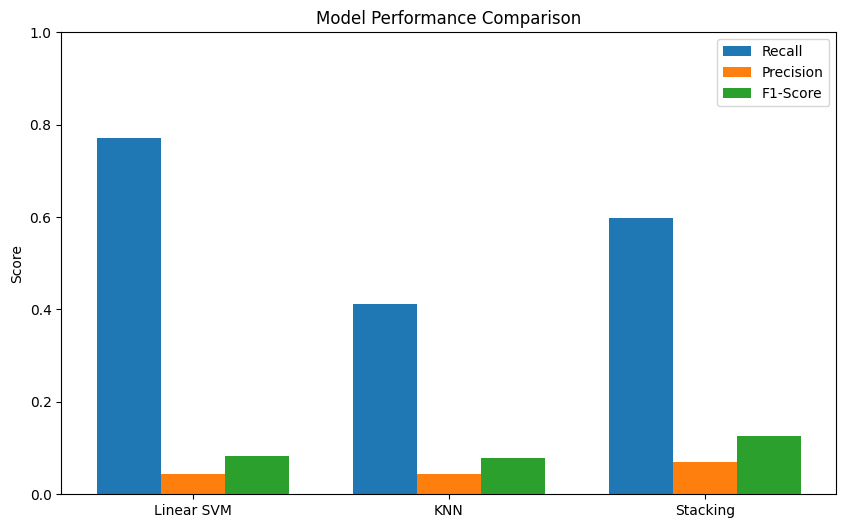

In [12]:
import matplotlib.pyplot as plt                                                                                                                                                                          
import numpy as np                                                                                                                                                                                       
                                                                                                                                                                                                        
models = ['Linear SVM', 'KNN', 'Stacking']                                                                                                                                                               
recall= [0.7711, 0.4116, 0.5979]                                                                                                                                                                     
precision =[0.0438, 0.0431, 0.0705]                                                                                                                                                                  
f1 =[0.0829, 0.0780, 0.1262]        
                                        
x = np.arange(len(models))                                                                                                                                                                               
width = 0.25                                                                                                                                                                                             
                                                                                                                                                                                                        
fig, ax = plt.subplots(figsize=(10, 6))                                                                                                                                                                  
ax.bar(x - width, recall, width, label='Recall')                                                                                                                                                         
ax.bar(x, precision, width, label='Precision')                                                                                                                                                           
ax.bar(x + width, f1, width, label='F1-Score')                                                                                                                                                           
                                                                                                                                                                                                        
ax.set_ylabel('Score')                                                                                                                                                                                   
ax.set_title('Model Performance Comparison')                                                                                                                                                             
ax.set_xticks(x)                                                                                                                                                                                         
ax.set_xticklabels(models)                                                                                                                                                                               
ax.legend()                                                                                                                                                                                              
ax.set_ylim(0, 1)                                                                                                                                                                                                                                                                                                                                                                      
plt.show()    

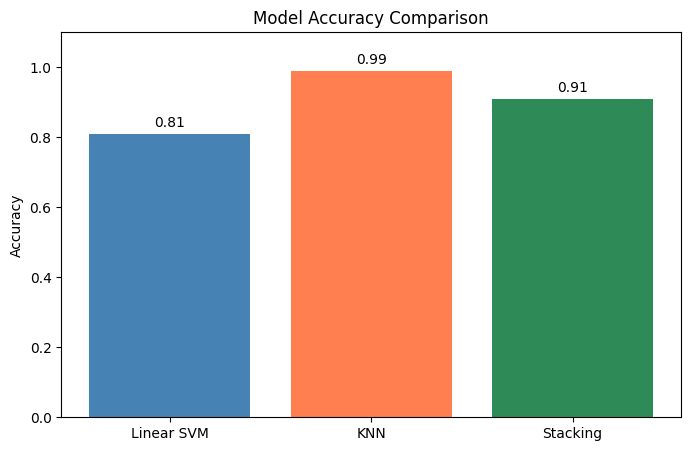

In [13]:
models = ['Linear SVM', 'KNN', 'Stacking']                                                                                                                                                               
accuracy = [0.81, 0.99, 0.91]                                                                                                                                                                            
                                                                                                                                                                                                        
fig, ax = plt.subplots(figsize=(8, 5))                                                                                                                                                                   
bars = ax.bar(models, accuracy, color=['steelblue', 'coral', 'seagreen'])                                                                                                                                
ax.set_ylabel('Accuracy')                                                                                                                                                                                
ax.set_title('Model Accuracy Comparison')                                                                                                                                                                
ax.set_ylim(0, 1.1)                                                                                                                                                                                        
                                                                                                                                                                                           
for bar, val in zip(bars, accuracy):                                                                                                                                                                     
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}', ha='center')                                                                                                                                                                                                                                                                                                                             
plt.show()